---
##Lotka-Volterra predator-prey model
---
The Lotka–Volterra model is a classic example of a system of differential equations representing interactions between prey and predators:


\begin{cases}
\frac{dx}{dt} = \alpha x - \beta x y \quad &\text{(prey growth minus predation)} \\
\frac{dy}{dt} = \delta x y - \gamma y \quad &\text{(predator growth from prey minus natural death)}
\end{cases}

Where:

* x(t) = prey population
*	y(t) = predator population
*	$\alpha, \beta, \delta, \gamma$ are model parameters
---
###Typical interpretation of parameters
---
e.g. for Fox-Rabbit (🦊🐇) per month:

| Parameter | Value | Description |
|-----------|-------|-------------|
| $\alpha$  | 1.0   | Rabbit (prey) birth rate |
| $\beta$   | 0.05  | Predation rate (fox encounters rabbits) |
| $\delta$  | 0.01  | Fox (predator) reproduction per rabbit eaten |
| $\gamma$  | 0.5   | Fox (predator) natural death rate |

---
*$\alpha = 1.0$* - each rabbit (male or female) contributes (on average) 1 new rabbit per month (net growth). Rabbits have a short gestation period of around 30-33 days, and a doe (female rabbit) can become pregnant again within hours of giving birth.

*$\beta x y$* is the rate at which prey are removed due to interactions with predators.

*$\delta$* - each fox (male or female) needs to eat $1/\delta$ rabbits to contribute to bring to life one fox cub.

*$\gamma = 0.5$* means each individual fox has a 50% chance of dying in a month if no food is available. That can simulate a harsh environment where predators are highly dependent on prey availability. Actual foxes (e.g., red foxes) in the wild have annual mortality rates of 30–60%, especially for juveniles.
*	Adult foxes can live several years.
*	Juveniles often experience high mortality after leaving the den.


In [ ]:
import numpy as np
from scipy.integrate import odeint #integrates ordinary differential equations
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit #optimises parameters to fit a fn to data
import matplotlib.pyplot as plt

# True parameters
alpha, beta, delta, gamma = 0.6, 0.02, 0.01, 0.5
params_true = (alpha, beta, delta, gamma)

# Time grid: 30 time units split into 300 time steps
t = np.linspace(0, 30, 300)
initial_pop = [40, 9]

# Lotka-Volterra model: here we define the ordinary differential equations
def lotka_volterra(pop, t, alpha, beta, delta, gamma):
    x, y = pop
    dxdt = alpha * x - beta * x * y
    dydt = delta * x * y - gamma * y
    return [dxdt, dydt]

# Generate true solution: given the first derivatives, initial state,
# time grid and set of parameters, find the values of x and y over time.
true_solution = odeint(lotka_volterra, initial_pop, t, args=params_true)
x_true, y_true = true_solution[:, 0], true_solution[:, 1]

# Add noise
np.random.seed(1)
x_noisy = x_true + np.random.normal(0, 5, size=x_true.shape)
y_noisy = y_true + np.random.normal(0, 4, size=y_true.shape)

# For fitting
def solve_and_flatten(t, alpha, beta, delta, gamma):
    sol = odeint(lotka_volterra, initial_pop, t, args=(alpha, beta, delta, gamma))
    return np.concatenate([sol[:, 0], sol[:, 1]])

# Combine the x and y observations
observed_data = np.concatenate([x_noisy, y_noisy])
# Initial guess about the parameters
p0 = [0.5, 0.01, 0.012, 0.5]
# All parameters are expected to be between 0 and infinity.
bounds = (0, np.inf)

#Fit the ODE equations on the data, return the optimal parameters.
popt, _ = curve_fit(solve_and_flatten, t, observed_data, p0=p0, bounds=bounds)
'''
The second return value (ignored here) is the parameter covariance matrix:
- pcov[i,j] is the estimated covariance between the i-th and j-th parameters.
- The diagonal values (pcov[i,i]) are the estimated variances of each parameter.
- The square root of each diagonal entry gives the standard error of the
  corresponding parameter.
'''

# Fitted solution
fitted_solution = odeint(lotka_volterra, initial_pop, t, args=tuple(popt))
x_fit, y_fit = fitted_solution[:, 0], fitted_solution[:, 1]

# Extract fitted parameters
alpha_fit, beta_fit, delta_fit, gamma_fit = popt

# Print fitted parameters nicely
print("Fitted Lotka–Volterra Parameters:")
print(f"  alpha (prey birth rate):     {alpha_fit:.4f}")
print(f"  beta  (predation rate):      {beta_fit:.4f}")
print(f"  delta (predator growth):     {delta_fit:.4f}")
print(f"  gamma (predator death rate): {gamma_fit:.4f}")

Fitted Lotka–Volterra Parameters:
  alpha (prey birth rate):     0.5946
  beta  (predation rate):      0.0198
  delta (predator growth):     0.0100
  gamma (predator death rate): 0.5053


---
##More about curve_fit
---
It uses non-linear least squares to fit a function to data:

https://docs.scipy.org/doc/scipy-0.13.0/reference/generated/scipy.optimize.curve_fit.html

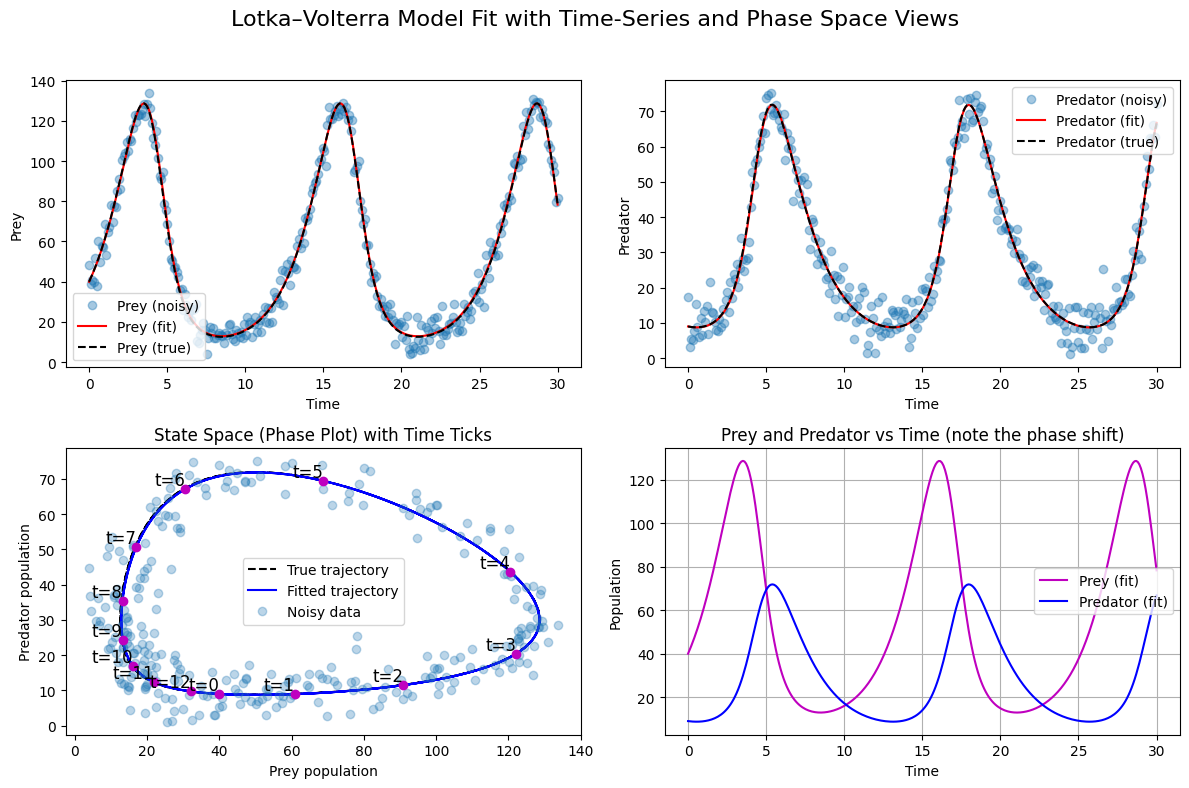

In [ ]:
# Plotting
plt.figure(figsize=(12, 8))

# Subplot 1: Prey
plt.subplot(2, 2, 1)
plt.plot(t, x_noisy, 'o', label='Prey (noisy)', alpha=0.4)
plt.plot(t, x_fit, 'r-', label='Prey (fit)')
plt.plot(t, x_true, 'k--', label='Prey (true)')
plt.xlabel('Time')
plt.ylabel('Prey')
plt.legend()

# Subplot 2: Predator
plt.subplot(2, 2, 2)
plt.plot(t, y_noisy, 'o', label='Predator (noisy)', alpha=0.4)
plt.plot(t, y_fit, 'r-', label='Predator (fit)')
plt.plot(t, y_true, 'k--', label='Predator (true)')
plt.xlabel('Time')
plt.ylabel('Predator')
plt.legend()

# Subplot 3: Phase plot with time ticks
plt.subplot(2, 2, 3)
plt.plot(x_true, y_true, 'k--', label='True trajectory')
plt.plot(x_fit, y_fit, 'b-', label='Fitted trajectory')
plt.plot(x_noisy, y_noisy, 'o', alpha=0.3, label='Noisy data')

# Add time ticks every 1 unit of time (t[0]..t[120] represents 12 units of time)
tick_times = np.arange(0, t[120], 1)
tick_indices = [np.abs(t - tick).argmin() for tick in tick_times]
for idx, tick in zip(tick_indices, tick_times):
    plt.plot(x_fit[idx], y_fit[idx], 'mo')  # time marker - colour and shape
    plt.text(x_fit[idx], y_fit[idx], f't={tick:.0f}', fontsize=12, ha='right', va='bottom')

plt.xlabel('Prey population')
plt.ylabel('Predator population')
plt.title('State Space (Phase Plot) with Time Ticks')
plt.legend()

# Subplot 4: Combined time vs prey & predator
plt.subplot(2, 2, 4)
plt.plot(t, x_fit, label='Prey (fit)', color='m')
plt.plot(t, y_fit, label='Predator (fit)', color='b')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Prey and Predator vs Time (note the phase shift)')
plt.grid(True)
plt.legend()

plt.suptitle('Lotka–Volterra Model Fit with Time-Series and Phase Space Views', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

##Accessibility tile: choose the best colours for you

If you want to see all named colours available in matplotlib, run this:




In [ ]:
import matplotlib
import matplotlib.pyplot as plt

colours = matplotlib.colors.get_named_colors_mapping()

# Adjust spacing between colour names
line_spacing = 1.5  # Try 2 for even more space

# Plot a sample of each colour
fig, ax = plt.subplots(figsize=(8, int(len(colours) * line_spacing * 0.1)))  # auto scale height

for i, (name, hex) in enumerate(sorted(colours.items())):
    ax.text(0, i * line_spacing, name, fontsize=10, color=hex)

ax.set_xlim(0, 1)
ax.set_ylim(0, len(colours) * line_spacing)
ax.axis('off')
plt.title('Named Matplotlib Colours', fontsize=14)
plt.tight_layout()
plt.show()